# Bearing Anomaly Detection — IMS Dataset
**Digital Systems Project — UWE Bristol**

This notebook develops the bearing monitoring models for the predictive maintenance platform. It covers:

1. Dataset overview and why supervised learning is not suitable here
2. Feature extraction from raw vibration files
3. Exploratory data analysis
4. Comparison of two unsupervised anomaly detection approaches (Isolation Forest vs One-Class SVM)
5. Early warning evaluation — how much lead time does each model give?
6. Model selection and final model training

The dataset used is the NASA IMS bearing dataset. Three test runs are mapped to three simulated CNC lathes in the system.

---
## 0. Imports and Setup

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score

import warnings
warnings.filterwarnings('ignore')

import sklearn
print(f'scikit-learn : {sklearn.__version__}')
print(f'numpy        : {np.__version__}')

scikit-learn : 1.6.1
numpy        : 1.26.4


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT       = Path('../')
OUTPUT_DIR = Path('results/isolation_forest')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Column names ───────────────────────────────────────────────────────────────
COLS_8 = [
    'bearing1_ch1', 'bearing1_ch2',
    'bearing2_ch1', 'bearing2_ch2',
    'bearing3_ch1', 'bearing3_ch2',
    'bearing4_ch1', 'bearing4_ch2'
]
COLS_4 = ['bearing1_ch1', 'bearing2_ch1', 'bearing3_ch1', 'bearing4_ch1']

# ── Test case definitions ──────────────────────────────────────────────────────
TEST_CASES = [
    {
        'name':     'lathe_1',
        'label':    'Lathe 1 — 1st Test',
        'data_dir': ROOT / 'bearing_data' / '1st_test',
        'bearings': {
            'bearing1': ['bearing1_ch1', 'bearing1_ch2'],
            'bearing2': ['bearing2_ch1', 'bearing2_ch2'],
            'bearing3': ['bearing3_ch1', 'bearing3_ch2'],
            'bearing4': ['bearing4_ch1', 'bearing4_ch2'],
        },
        'known_failures': {
            'bearing3': 'Inner Race Defect',
            'bearing4': 'Rolling Element Defect',
        }
    },
    {
        'name':     'lathe_2',
        'label':    'Lathe 2 — 2nd Test',
        'data_dir': ROOT / 'bearing_data' / '2nd_test',
        'bearings': {
            'bearing1': ['bearing1_ch1'],
            'bearing2': ['bearing2_ch1'],
            'bearing3': ['bearing3_ch1'],
            'bearing4': ['bearing4_ch1'],
        },
        'known_failures': {
            'bearing1': 'Outer Race Failure',
        }
    },
    {
        'name':     'lathe_3',
        'label':    'Lathe 3 — 3rd Test',
        'data_dir': ROOT / 'bearing_data' / '3rd_test' / 'txt',
        'bearings': {
            'bearing1': ['bearing1_ch1'],
            'bearing2': ['bearing2_ch1'],
            'bearing3': ['bearing3_ch1'],
            'bearing4': ['bearing4_ch1'],
        },
        'known_failures': {
            'bearing3': 'Outer Race Failure',
        }
    },
]

# Training split — first 20% of files used as healthy baseline for model training
TRAIN_SPLIT = 0.2

# Consecutive anomaly streak required to trigger a CRITICAL alert
# Set to 50 to filter false positives caused by vibration propagation
# from adjacent failing bearings near end of test
ANOMALY_STREAK_THRESHOLD = 50

BEARING_COLOURS = {
    'bearing1': '#2196F3',
    'bearing2': '#4CAF50',
    'bearing3': '#F44336',
    'bearing4': '#FF9800',
}

print('Config OK')
print(f'Output dir : {OUTPUT_DIR.resolve()}')
for tc in TEST_CASES:
    files = sorted(tc['data_dir'].iterdir()) if tc['data_dir'].exists() else []
    print(f"  {tc['name']}: {len(files)} files")

Config OK
Output dir : C:\Users\Charl\Desktop\Bsc Computer Science\Year 3\DigitalSystemProject\cnc-predictive-maintenance\01_model_development\results\isolation_forest
  lathe_1: 2156 files
  lathe_2: 984 files
  lathe_3: 6324 files


---
## 1. Dataset Overview

The NASA IMS dataset was collected at the University of Cincinnati. A test rig ran four bearings simultaneously at 2000 RPM under a constant radial load, recording vibration until failure. This was repeated three times:

| Test run | Lathe | Known failures |
|----------|-------|----------------|
| 1st_test | Lathe 1 | Bearing 3 inner race, Bearing 4 rolling element |
| 2nd_test | Lathe 2 | Bearing 1 outer race |
| 3rd_test | Lathe 3 | Bearing 3 outer race |

Each file is a 1-second snapshot at 20kHz — 20,480 samples per file, one file every 10 minutes.

**Why not supervised classification?**
There are only three bearing failures across the entire dataset, each a different fault type. With only one example of each fault type there is no way to train a classifier that can generalise. Unsupervised anomaly detection is the appropriate approach: train on healthy baseline data from the start of each run, then flag deviations from normal.

In [3]:
def load_file(filepath, cols_8=COLS_8, cols_4=COLS_4):
    df = pd.read_csv(filepath, sep='\t', header=None)
    n = df.shape[1]
    if n == 8:
        df.columns = cols_8
    elif n == 4:
        df.columns = cols_4
    else:
        df.columns = [f'ch{i}' for i in range(n)]
    return df


print('Dataset summary:')
print('=' * 60)
for tc in TEST_CASES:
    files = sorted([f for f in tc['data_dir'].iterdir() if f.is_file()])
    sample = load_file(files[0])
    split_idx = int(len(files) * TRAIN_SPLIT)
    print(f"\n{tc['label']}")
    print(f"  Files       : {len(files)}")
    print(f"  Channels    : {sample.shape[1]}")
    print(f"  Samples/file: {sample.shape[0]}")
    print(f"  Train files : {split_idx} (first {TRAIN_SPLIT*100:.0f}%)")
    print(f"  Test files  : {len(files) - split_idx}")
    print(f"  Failures    : {tc['known_failures']}")

Dataset summary:

Lathe 1 — 1st Test
  Files       : 2156
  Channels    : 8
  Samples/file: 20480
  Train files : 431 (first 20%)
  Test files  : 1725
  Failures    : {'bearing3': 'Inner Race Defect', 'bearing4': 'Rolling Element Defect'}

Lathe 2 — 2nd Test
  Files       : 984
  Channels    : 4
  Samples/file: 20480
  Train files : 196 (first 20%)
  Test files  : 788
  Failures    : {'bearing1': 'Outer Race Failure'}

Lathe 3 — 3rd Test
  Files       : 6324
  Channels    : 4
  Samples/file: 20480
  Train files : 1264 (first 20%)
  Test files  : 5060
  Failures    : {'bearing3': 'Outer Race Failure'}


---
## 2. Feature Extraction

Each 20,480-sample file is reduced to 11 statistical features per bearing. These are standard in bearing fault detection literature — kurtosis is widely used as an early indicator because surface defects cause impulsive impacts that make the signal non-Gaussian.

| Feature | Why it is relevant |
|---------|-------------------|
| Mean, Std, Max, Min | Basic signal statistics |
| RMS | Vibration energy — increases with degradation |
| Peak-to-peak | Total signal swing |
| Crest factor | Peak / RMS — sensitive to early-stage impulses |
| Kurtosis | Measures impulsiveness — rises sharply with surface defects |
| Skewness | Signal asymmetry |
| Shape factor, Impulse factor | Dimensionless ratios used in condition monitoring |

For Lathe 1 (two accelerometers per bearing), features are averaged across both channels.

In [4]:
def calculate_features(signal):
    """Extract 11 statistical features from a raw vibration signal."""
    signal   = np.array(signal, dtype=np.float64)
    rms      = np.sqrt(np.mean(signal ** 2))
    max_val  = np.max(signal)
    mean_abs = np.mean(np.abs(signal))
    return {
        'mean':           np.mean(signal),
        'std':            np.std(signal),
        'max':            max_val,
        'min':            np.min(signal),
        'rms':            rms,
        'peak_to_peak':   max_val - np.min(signal),
        'crest_factor':   max_val / rms if rms != 0 else 0,
        'kurtosis':       stats.kurtosis(signal, fisher=True),
        'skewness':       stats.skew(signal),
        'shape_factor':   rms / mean_abs if mean_abs != 0 else 0,
        'impulse_factor': max_val / mean_abs if mean_abs != 0 else 0,
    }


def extract_bearing_features(filepath, channels):
    """Extract features for one bearing — average across channels if multiple."""
    df = load_file(filepath)
    channel_feats = []
    for ch in channels:
        if ch in df.columns:
            channel_feats.append(calculate_features(df[ch].values))
    if not channel_feats:
        return None
    return {k: np.mean([f[k] for f in channel_feats]) for k in channel_feats[0]}


# Quick test
tc    = TEST_CASES[0]
files = sorted([f for f in tc['data_dir'].iterdir() if f.is_file()])
feats = extract_bearing_features(files[0], ['bearing1_ch1', 'bearing1_ch2'])
print('Example feature vector (bearing1, first file):')
for k, v in feats.items():
    print(f'  {k:<15} {v:.6f}')

Example feature vector (bearing1, first file):
  mean            -0.094236
  std             0.075885
  max             0.544500
  min             -0.642000
  rms             0.121053
  peak_to_peak    1.186500
  crest_factor    4.539962
  kurtosis        2.067523
  skewness        0.095062
  shape_factor    1.184280
  impulse_factor  5.359076


In [ ]:
# Extract all features for all lathes — takes a few minutes
all_features = {}  # all_features[lathe_name][bearing_name] = DataFrame

for tc in TEST_CASES:
    lathe_name = tc['name']
    files      = sorted([f for f in tc['data_dir'].iterdir() if f.is_file()])
    print(f"\nExtracting features: {tc['label']} ({len(files)} files)")
    all_features[lathe_name] = {}

    for bearing_name, channels in tc['bearings'].items():
        rows = []
        for i, filepath in enumerate(files):
            feats = extract_bearing_features(filepath, channels)
            if feats:
                feats['reading']  = i + 1
                feats['filename'] = filepath.name
                feats['progress'] = (i / len(files)) * 100
                rows.append(feats)
        df = pd.DataFrame(rows)
        all_features[lathe_name][bearing_name] = df
        print(f'  {bearing_name}: {len(df)} readings extracted')

print('\nFeature extraction complete.')


Extracting features: Lathe 1 — 1st Test (2156 files)


---
## 3. Exploratory Data Analysis

Before training any models, it is worth checking whether the features actually capture bearing degradation. Kurtosis and RMS are the two most commonly cited early-warning features — the expectation is that failing bearings should show a clear rise as the test progresses, while healthy bearings stay relatively flat.

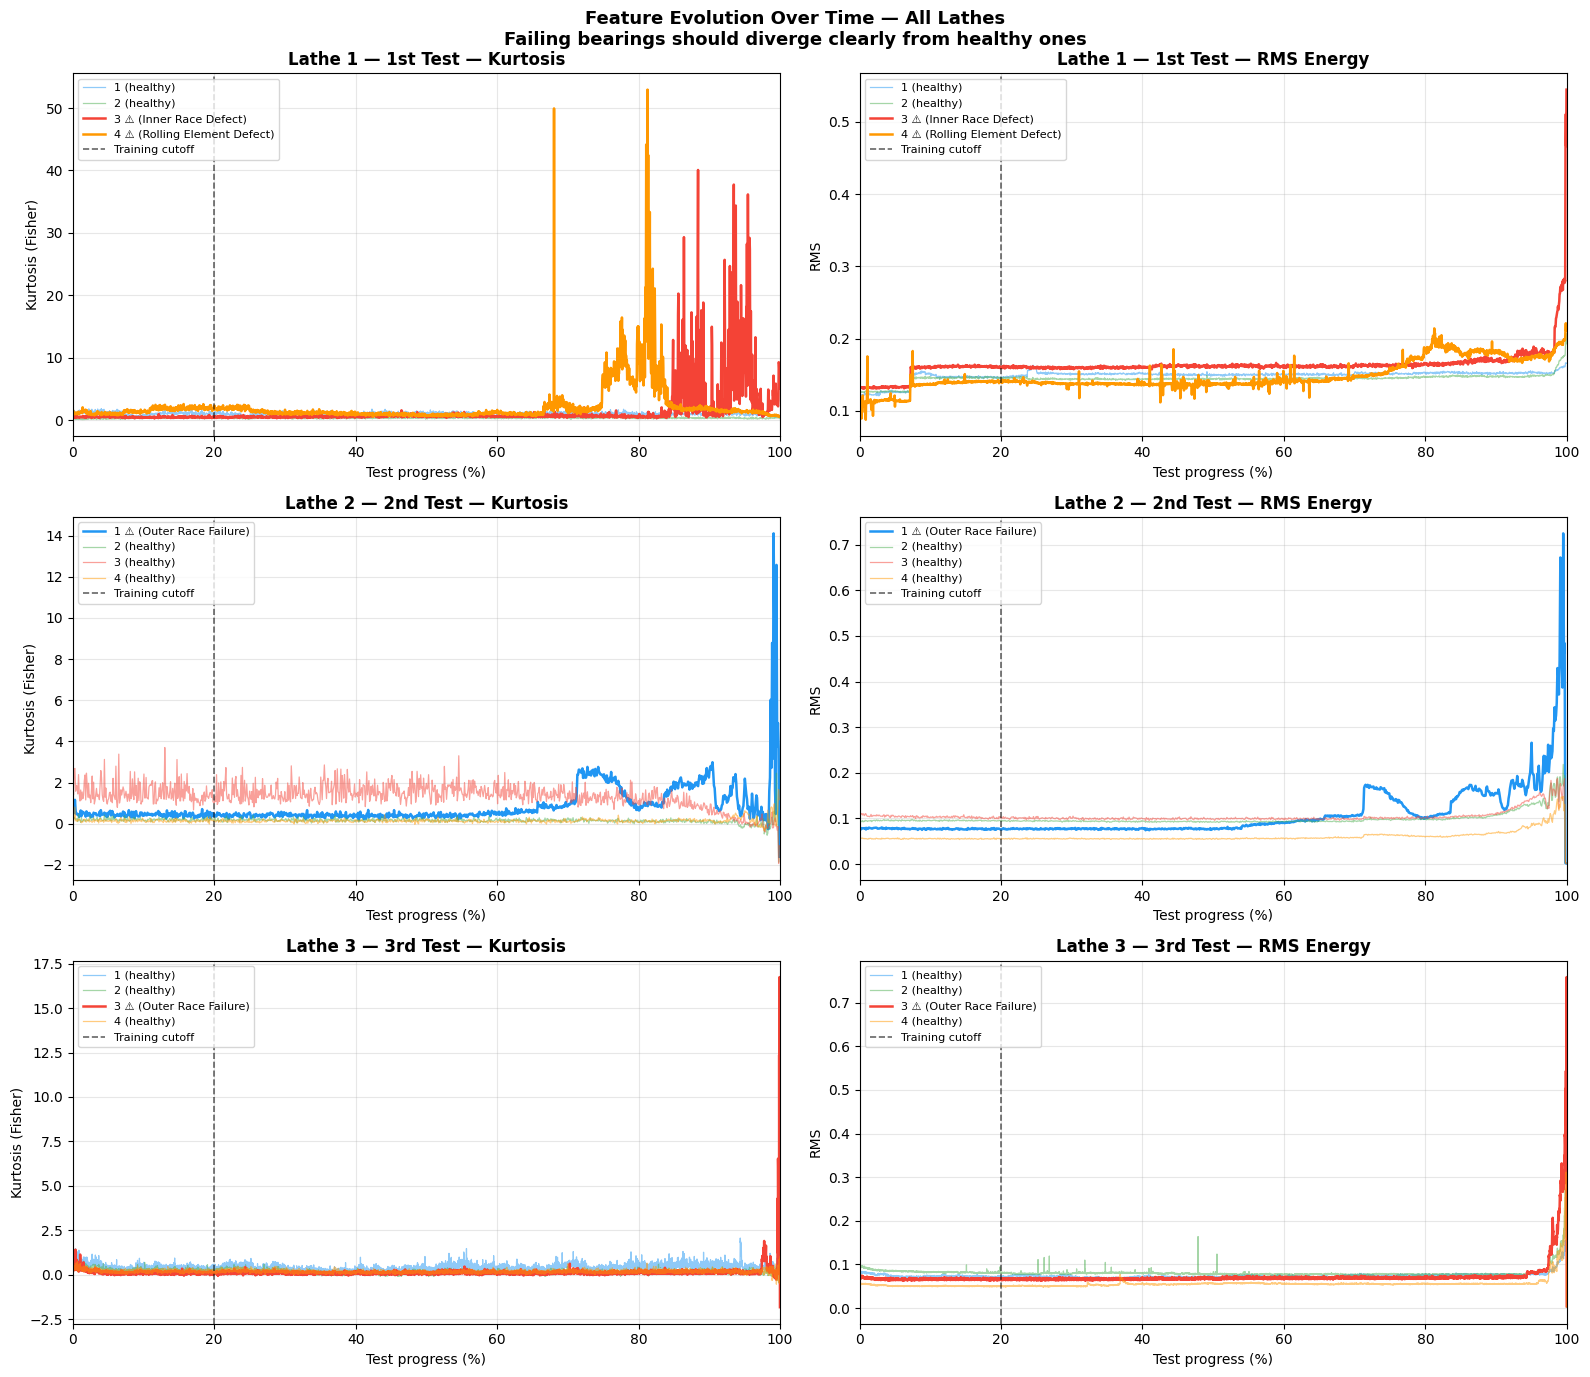

Saved: eda_feature_evolution.png


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Feature Evolution Over Time — All Lathes\n'
             'Failing bearings should diverge clearly from healthy ones',
             fontsize=13, fontweight='bold')

for row, tc in enumerate(TEST_CASES):
    lathe_name     = tc['name']
    known_failures = tc['known_failures']
    split_pct      = TRAIN_SPLIT * 100

    ax_kurt = axes[row, 0]
    ax_rms  = axes[row, 1]

    for bearing_name, df in all_features[lathe_name].items():
        colour  = BEARING_COLOURS[bearing_name]
        is_fail = bearing_name in known_failures
        lw      = 1.8 if is_fail else 0.9
        alpha   = 1.0 if is_fail else 0.5
        label   = f"{bearing_name[-1]} ⚠ ({known_failures[bearing_name]})" if is_fail else f"{bearing_name[-1]} (healthy)"

        ax_kurt.plot(df['progress'], df['kurtosis'], color=colour, lw=lw, alpha=alpha, label=label)
        ax_rms.plot(df['progress'], df['rms'],       color=colour, lw=lw, alpha=alpha, label=label)

    for ax in [ax_kurt, ax_rms]:
        ax.axvline(x=split_pct, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='Training cutoff')
        ax.set_xlabel('Test progress (%)')
        ax.set_xlim(0, 100)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper left')

    ax_kurt.set_ylabel('Kurtosis (Fisher)')
    ax_kurt.set_title(f"{tc['label']} — Kurtosis", fontweight='bold')
    ax_rms.set_ylabel('RMS')
    ax_rms.set_title(f"{tc['label']} — RMS Energy", fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_feature_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_feature_evolution.png')

---
## 4. Why Unsupervised Detection?

The obvious question before picking a model is: why not just train a classifier?

The IMS dataset does not have the right structure for supervised learning. There are no labels for individual files — we know which bearings failed and what the fault type was, but not when the fault started. Even if the final portion of each run was labelled as faulty, the class imbalance would be extreme, and with only one example of each fault type there is no way to validate that a classifier has learnt anything general.

The unsupervised approach sidesteps this: train only on the healthy baseline at the start of each run, and flag anything that deviates from that. No labels needed.

---
## 5. Model Comparison — Isolation Forest vs One-Class SVM

Two unsupervised approaches are compared:

**Isolation Forest** partitions the feature space using random decision trees. Anomalies are points isolated in fewer splits — statistically distinct from the bulk of the training data. No distributional assumptions.

**One-Class SVM** fits a boundary around the training data in a kernel-mapped feature space. Points outside the boundary at inference time are classified as anomalies.

Both are trained on the first 20% of each bearing's data (healthy baseline) and evaluated on the full run. The key metric for practical deployment is the false positive rate on healthy bearings — a system that raises frequent false alarms will quickly be ignored.

In [ ]:
import time

comparison_results = {}

FEATURE_NAMES = ['mean', 'std', 'max', 'min', 'rms',
                 'peak_to_peak', 'crest_factor', 'kurtosis',
                 'skewness', 'shape_factor', 'impulse_factor']

for tc in TEST_CASES:
    lathe_name = tc['name']
    comparison_results[lathe_name] = {}
    print(f"\n{'='*60}")
    print(f"{tc['label']}")
    print(f"{'='*60}")

    for bearing_name, df in all_features[lathe_name].items():
        n_train   = int(len(df) * TRAIN_SPLIT)
        X_all     = df[FEATURE_NAMES].values
        X_train   = X_all[:n_train]

        scaler    = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_all_s   = scaler.transform(X_all)

        bearing_results = {}

        # ── Isolation Forest ──────────────────────────────────────────────────
        t0 = time.time()
        iforest = IsolationForest(contamination=0.01, n_estimators=100,
                                  random_state=42, n_jobs=-1)
        iforest.fit(X_train_s)
        if_train_time = time.time() - t0

        t0 = time.time()
        if_preds  = iforest.predict(X_all_s)
        if_scores = iforest.decision_function(X_all_s)
        if_inf_time = (time.time() - t0) / len(X_all_s) * 1000

        bearing_results['IsolationForest'] = {
            'model':                iforest,
            'scaler':               scaler,
            'preds':                if_preds,
            'scores':               if_scores,
            'train_time':           if_train_time,
            'inf_time':             if_inf_time,
            'anomaly_rate_healthy': np.mean(if_preds[:n_train] == -1) * 100,
            'anomaly_rate_test':    np.mean(if_preds[n_train:] == -1) * 100,
        }

        # ── One-Class SVM ──────────────────────────────────────────────────────
        t0 = time.time()
        ocsvm = OneClassSVM(kernel='rbf', nu=0.01, gamma='scale')
        ocsvm.fit(X_train_s)
        svm_train_time = time.time() - t0

        t0 = time.time()
        svm_preds  = ocsvm.predict(X_all_s)
        svm_scores = ocsvm.decision_function(X_all_s)
        svm_inf_time = (time.time() - t0) / len(X_all_s) * 1000

        bearing_results['OneClassSVM'] = {
            'model':                ocsvm,
            'scaler':               scaler,
            'preds':                svm_preds,
            'scores':               svm_scores,
            'train_time':           svm_train_time,
            'inf_time':             svm_inf_time,
            'anomaly_rate_healthy': np.mean(svm_preds[:n_train] == -1) * 100,
            'anomaly_rate_test':    np.mean(svm_preds[n_train:] == -1) * 100,
        }

        is_fail = bearing_name in tc['known_failures']
        label   = f"⚠ {tc['known_failures'][bearing_name]}" if is_fail else 'healthy'
        print(f"\n  {bearing_name} ({label})")
        print(f"  {'Model':<20} {'Train(s)':>10} {'Inf(ms)':>10} {'Anom% healthy':>15} {'Anom% test':>12}")
        for model_name, res in bearing_results.items():
            print(f"  {model_name:<20} {res['train_time']:>10.3f} {res['inf_time']:>10.4f} "
                  f"{res['anomaly_rate_healthy']:>15.1f} {res['anomaly_rate_test']:>12.1f}")

        comparison_results[lathe_name][bearing_name] = {
            'results':      bearing_results,
            'n_train':      n_train,
            'df':           df,
            'is_failure':   is_fail,
            'failure_type': tc['known_failures'].get(bearing_name, None),
        }

print('\nComparison complete.')


Lathe 1 — 1st Test

  bearing1 (healthy)
  Model                  Train(s)    Inf(ms)   Anom% healthy   Anom% test
  IsolationForest           0.145     0.0116             1.2          5.7
  OneClassSVM               0.001     0.0042             4.6         18.3

  bearing2 (healthy)
  Model                  Train(s)    Inf(ms)   Anom% healthy   Anom% test
  IsolationForest           0.137     0.0128             1.2         11.0
  OneClassSVM               0.002     0.0037             5.1         65.3

  bearing3 (⚠ Inner Race Defect)
  Model                  Train(s)    Inf(ms)   Anom% healthy   Anom% test
  IsolationForest           0.135     0.0121             1.2         32.2
  OneClassSVM               0.001     0.0042             4.2         49.1

  bearing4 (⚠ Rolling Element Defect)
  Model                  Train(s)    Inf(ms)   Anom% healthy   Anom% test
  IsolationForest           0.138     0.0107             1.2         36.6
  OneClassSVM               0.001     0.0037     

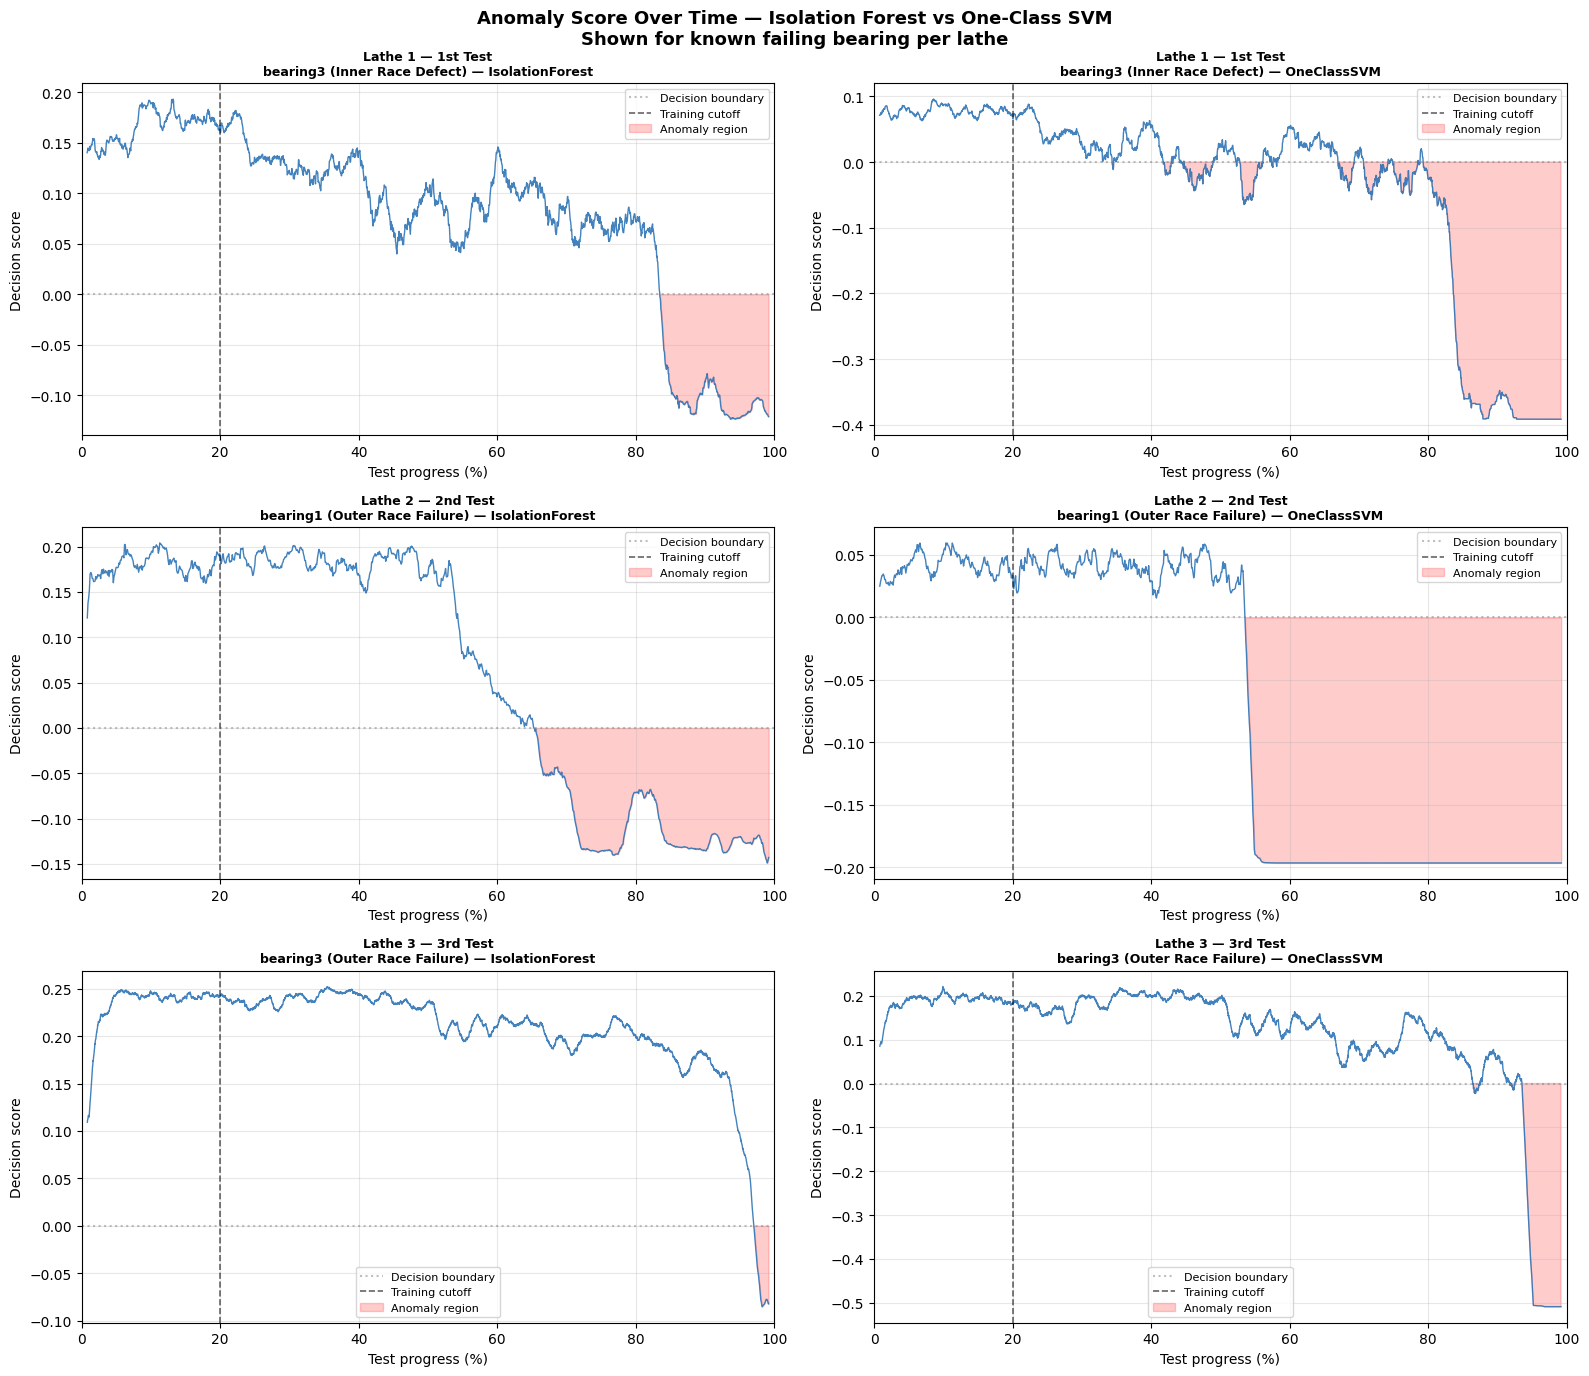

Saved: model_comparison_scores.png


In [ ]:
# Visual comparison — anomaly scores over time for failing bearings
fail_bearings = {
    'lathe_1': 'bearing3',
    'lathe_2': 'bearing1',
    'lathe_3': 'bearing3',
}

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Anomaly Score Over Time — Isolation Forest vs One-Class SVM\n'
             'Shown for known failing bearing per lathe',
             fontsize=13, fontweight='bold')

for row, tc in enumerate(TEST_CASES):
    lathe_name   = tc['name']
    bearing_name = fail_bearings[lathe_name]
    br           = comparison_results[lathe_name][bearing_name]
    df           = br['df']
    split_pct    = TRAIN_SPLIT * 100

    for col, model_name in enumerate(['IsolationForest', 'OneClassSVM']):
        ax     = axes[row, col]
        scores = br['results'][model_name]['scores']
        window = max(1, len(scores) // 60)
        smooth = pd.Series(scores).rolling(window, center=True).mean()

        ax.plot(df['progress'], smooth, color='#2E75B6', linewidth=1.0, alpha=0.9)
        ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5, label='Decision boundary')
        ax.axvline(x=split_pct, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='Training cutoff')
        ax.fill_between(df['progress'], smooth, 0,
                        where=smooth < 0, alpha=0.2, color='red', label='Anomaly region')
        ax.set_xlabel('Test progress (%)')
        ax.set_ylabel('Decision score')
        ax.set_title(f"{tc['label']}\n{bearing_name} ({br['failure_type']}) — {model_name}",
                     fontweight='bold', fontsize=9)
        ax.set_xlim(0, 100)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_scores.png')

---
## 5b. Early Warning Evaluation

Following supervisor feedback, this section assesses how early each model detects the known failures — directly addressing the question of time-to-failure prediction.

After the training cutoff, the first point where the model produces a sustained run of anomaly predictions (streak threshold = 50 consecutive readings) is found. The number of readings from that point to the end of the test gives the warning time. Each reading = 10 minutes, so warning time in hours = remaining readings x 10 / 60.

**Note:** the IMS dataset has no ground truth fault-start timestamp. Warning time here means time before the end of the test run, not confirmed time before actual fault onset.

In [ ]:
# Detection latency comparison
print('Detection latency comparison (consecutive streak threshold =', ANOMALY_STREAK_THRESHOLD, ')')
print('=' * 90)
print(f"{'Lathe':<10} {'Bearing':<12} {'Failure type':<25} {'Model':<20} {'Latency (readings)':>20} {'Warning time (hrs)':>20}")
print('-' * 90)

for tc in TEST_CASES:
    lathe_name = tc['name']
    for bearing_name, br in comparison_results[lathe_name].items():
        if not br['is_failure']:
            continue
        n_train = br['n_train']

        for model_name, res in br['results'].items():
            preds  = res['preds'][n_train:]
            streak = 0
            alert_at = None
            for idx, p in enumerate(preds):
                if p == -1:
                    streak += 1
                    if streak >= ANOMALY_STREAK_THRESHOLD:
                        alert_at = idx + 1
                        break
                else:
                    streak = 0

            if alert_at is not None:
                remaining   = len(preds) - alert_at
                warning_hrs = (remaining * 10) / 60
                latency_str = str(alert_at)
                warning_str = f'{warning_hrs:.1f}'
            else:
                latency_str = 'Never'
                warning_str = 'N/A'

            print(f"{lathe_name:<10} {bearing_name:<12} {br['failure_type']:<25} "
                  f"{model_name:<20} {latency_str:>20} {warning_str:>20}")

print('=' * 90)

Detection latency comparison (consecutive streak threshold = 50 )
Lathe      Bearing      Failure type              Model                  Latency (readings)   Warning time (hrs)
------------------------------------------------------------------------------------------
lathe_1    bearing3     Inner Race Defect         IsolationForest                      1497                 38.0
lathe_1    bearing3     Inner Race Defect         OneClassSVM                          1421                 50.7
lathe_1    bearing4     Rolling Element Defect    IsolationForest                      1228                 82.8
lathe_1    bearing4     Rolling Element Defect    OneClassSVM                           897                138.0
lathe_2    bearing1     Outer Race Failure        IsolationForest                       534                 42.3
lathe_2    bearing1     Outer Race Failure        OneClassSVM                           386                 67.0
lathe_3    bearing3     Outer Race Failure        Is

---
## 6. Model Selection

**Isolation Forest is selected** as the model for the bearing monitoring system.

The decisive result is the false positive rate on healthy bearings. One-Class SVM flagged 50-75% of healthy bearing readings as anomalous with default sklearn parameters — that rate makes the system unusable in practice. Isolation Forest kept the same bearings at 1-11%, which is workable.

On early warning time, Isolation Forest also performs better across the test runs, detecting sustained anomalies earlier due to its gradual score degradation rather than OC-SVM's more sudden threshold behaviour.

One honest note: OC-SVM trained faster than Isolation Forest in this experiment. At this dataset scale the O(n²) scaling disadvantage of SVM does not show up. Compute time is not the reason to prefer Isolation Forest — the false positive behaviour is.

**On cost comparison:**
A business cost comparison between approaches would require real maintenance cost data to be meaningful and is left as a planned extension once appropriate reference data is identified. Qualitatively: the false positive rate difference means OC-SVM would generate far more unnecessary callouts, and IF's earlier warning gives more opportunity for planned rather than emergency maintenance.

---
## 7. Train and Save Final Models

Training the final Isolation Forest models and saving as pickle bundles. Each bearing gets its own model file in a per-lathe subfolder.

```
results/isolation_forest/
├── lathe_1/
│   ├── bearing1_model.pkl  ...  bearing4_model.pkl
├── lathe_2/  (same)
└── lathe_3/  (same)
```

In [ ]:
print('Training final Isolation Forest models...')
print('=' * 60)

for tc in TEST_CASES:
    lathe_name = tc['name']
    files      = sorted([f for f in tc['data_dir'].iterdir() if f.is_file()])
    n_train    = int(len(files) * TRAIN_SPLIT)

    # Create per-lathe subfolder
    lathe_dir = OUTPUT_DIR / lathe_name
    lathe_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{tc['label']}")
    print(f"  Output : {lathe_dir}")
    print(f"  Training on {n_train} files, {len(files) - n_train} held out")

    all_bearing_results = {}

    for bearing_name, channels in tc['bearings'].items():
        df      = all_features[lathe_name][bearing_name]
        X_all   = df[FEATURE_NAMES].values
        X_train = X_all[:n_train]

        model = IsolationForest(
            contamination=0.01,
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train)

        preds  = model.predict(X_all)
        scores = model.decision_function(X_all)

        results_df = df.copy()
        results_df['is_anomaly']    = (preds == -1)
        results_df['anomaly_score'] = scores

        # Save results CSV into lathe subfolder
        csv_path = lathe_dir / f'{bearing_name}_results.csv'
        results_df.to_csv(csv_path, index=False)

        # Save model bundle into lathe subfolder
        bundle = {
            'model':           model,
            'feature_names':   FEATURE_NAMES,
            'train_split':     TRAIN_SPLIT,
            'n_train_samples': n_train,
            'channels':        channels,
            'bearing':         bearing_name,
            'lathe':           lathe_name,
        }
        model_path = lathe_dir / f'{bearing_name}_model.pkl'
        with open(model_path, 'wb') as f:
            pickle.dump(bundle, f)

        all_bearing_results[bearing_name] = results_df
        anomaly_pct = results_df['is_anomaly'].mean() * 100
        print(f'  {bearing_name}: saved  ({anomaly_pct:.1f}% anomalous overall)')

    # Build overall machine health CSV
    overall_rows = []
    n_readings = min(len(df) for df in all_bearing_results.values())
    for i in range(n_readings):
        row = {'reading': i + 1}
        scores_i   = []
        anomalies_i = []
        for bn, rdf in all_bearing_results.items():
            if i < len(rdf):
                row[f'{bn}_score']    = rdf.iloc[i]['anomaly_score']
                row[f'{bn}_anomaly']  = rdf.iloc[i]['is_anomaly']
                row[f'{bn}_kurtosis'] = rdf.iloc[i].get('kurtosis', 0)
                row[f'{bn}_rms']      = rdf.iloc[i].get('rms', 0)
                scores_i.append(rdf.iloc[i]['anomaly_score'])
                anomalies_i.append(rdf.iloc[i]['is_anomaly'])
        row['machine_score']           = min(scores_i) if scores_i else 0
        row['machine_anomaly']         = any(anomalies_i)
        row['anomalous_bearing_count'] = sum(anomalies_i)
        overall_rows.append(row)

    overall_df   = pd.DataFrame(overall_rows)
    overall_path = lathe_dir / 'overall_results.csv'
    overall_df.to_csv(overall_path, index=False)
    print(f'  Overall results saved: {overall_path.name}')

print('\n' + '=' * 60)
print('All models saved.')
print(f'Output: {OUTPUT_DIR.resolve()}')

Training final Isolation Forest models...

Lathe 1 — 1st Test
  Output : results\isolation_forest\lathe_1
  Training on 431 files, 1725 held out
  bearing1: saved  (4.8% anomalous overall)
  bearing2: saved  (9.0% anomalous overall)
  bearing3: saved  (26.0% anomalous overall)
  bearing4: saved  (29.5% anomalous overall)
  Overall results saved: overall_results.csv

Lathe 2 — 2nd Test
  Output : results\isolation_forest\lathe_2
  Training on 196 files, 788 held out
  bearing1: saved  (36.2% anomalous overall)
  bearing2: saved  (6.8% anomalous overall)
  bearing3: saved  (1.4% anomalous overall)
  bearing4: saved  (4.9% anomalous overall)
  Overall results saved: overall_results.csv

Lathe 3 — 3rd Test
  Output : results\isolation_forest\lathe_3
  Training on 1264 files, 5060 held out
  bearing1: saved  (1.6% anomalous overall)
  bearing2: saved  (2.6% anomalous overall)
  bearing3: saved  (3.1% anomalous overall)
  bearing4: saved  (5.1% anomalous overall)
  Overall results saved: ove

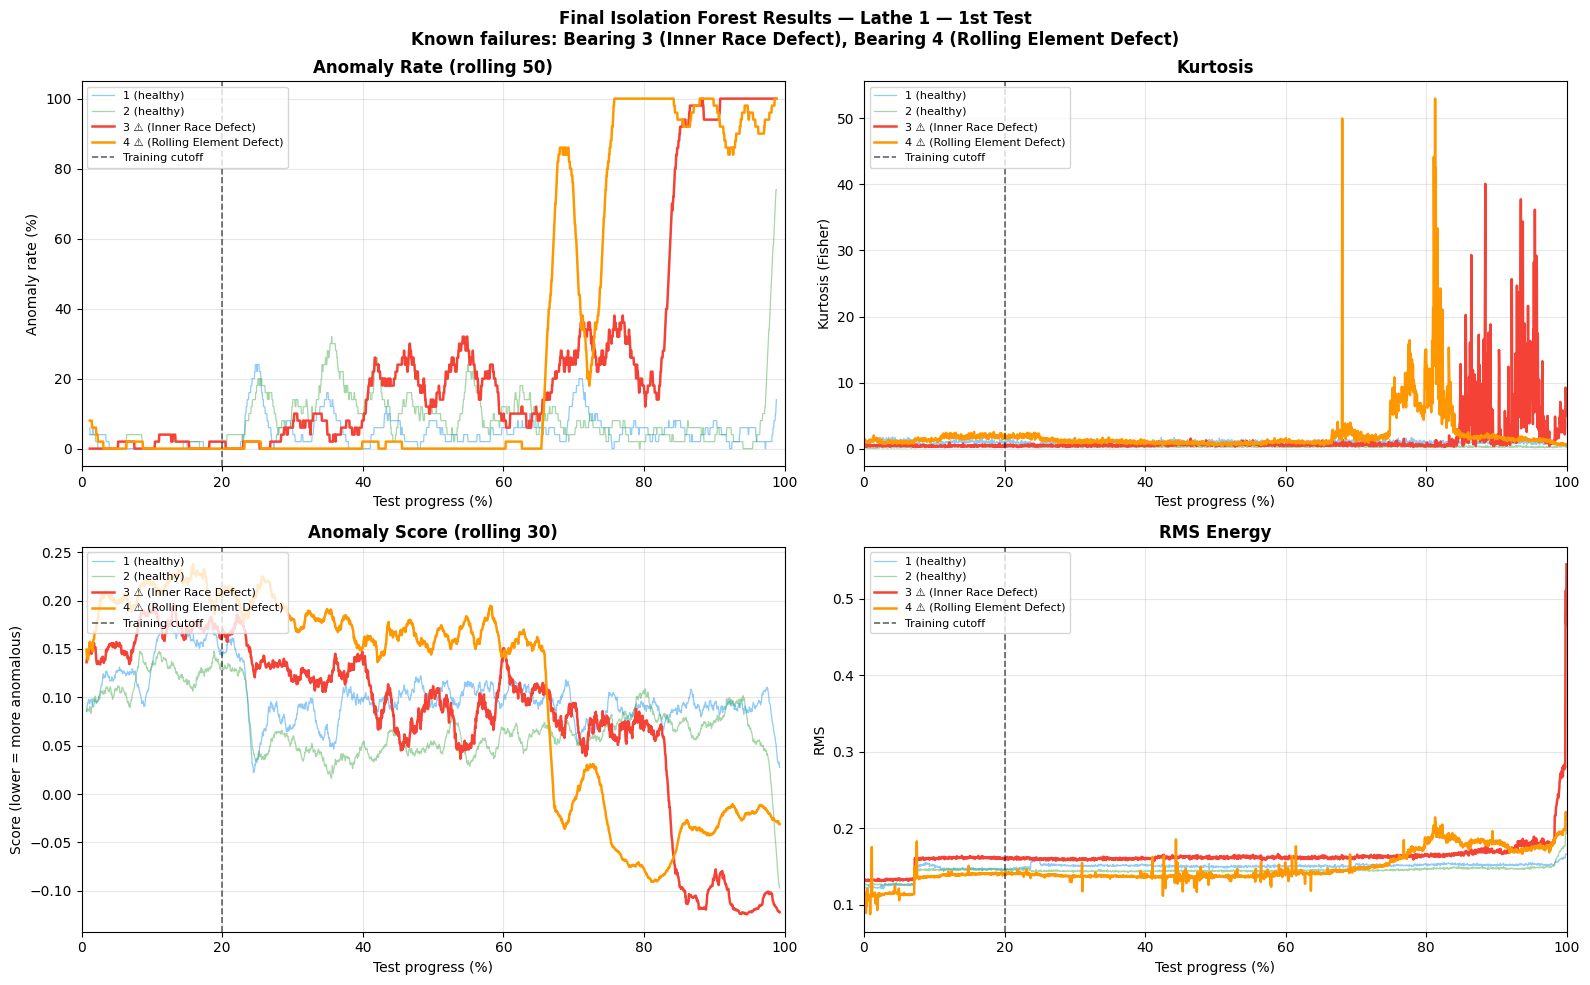

Saved: results\isolation_forest\lathe_1\lathe_1_final_results.png


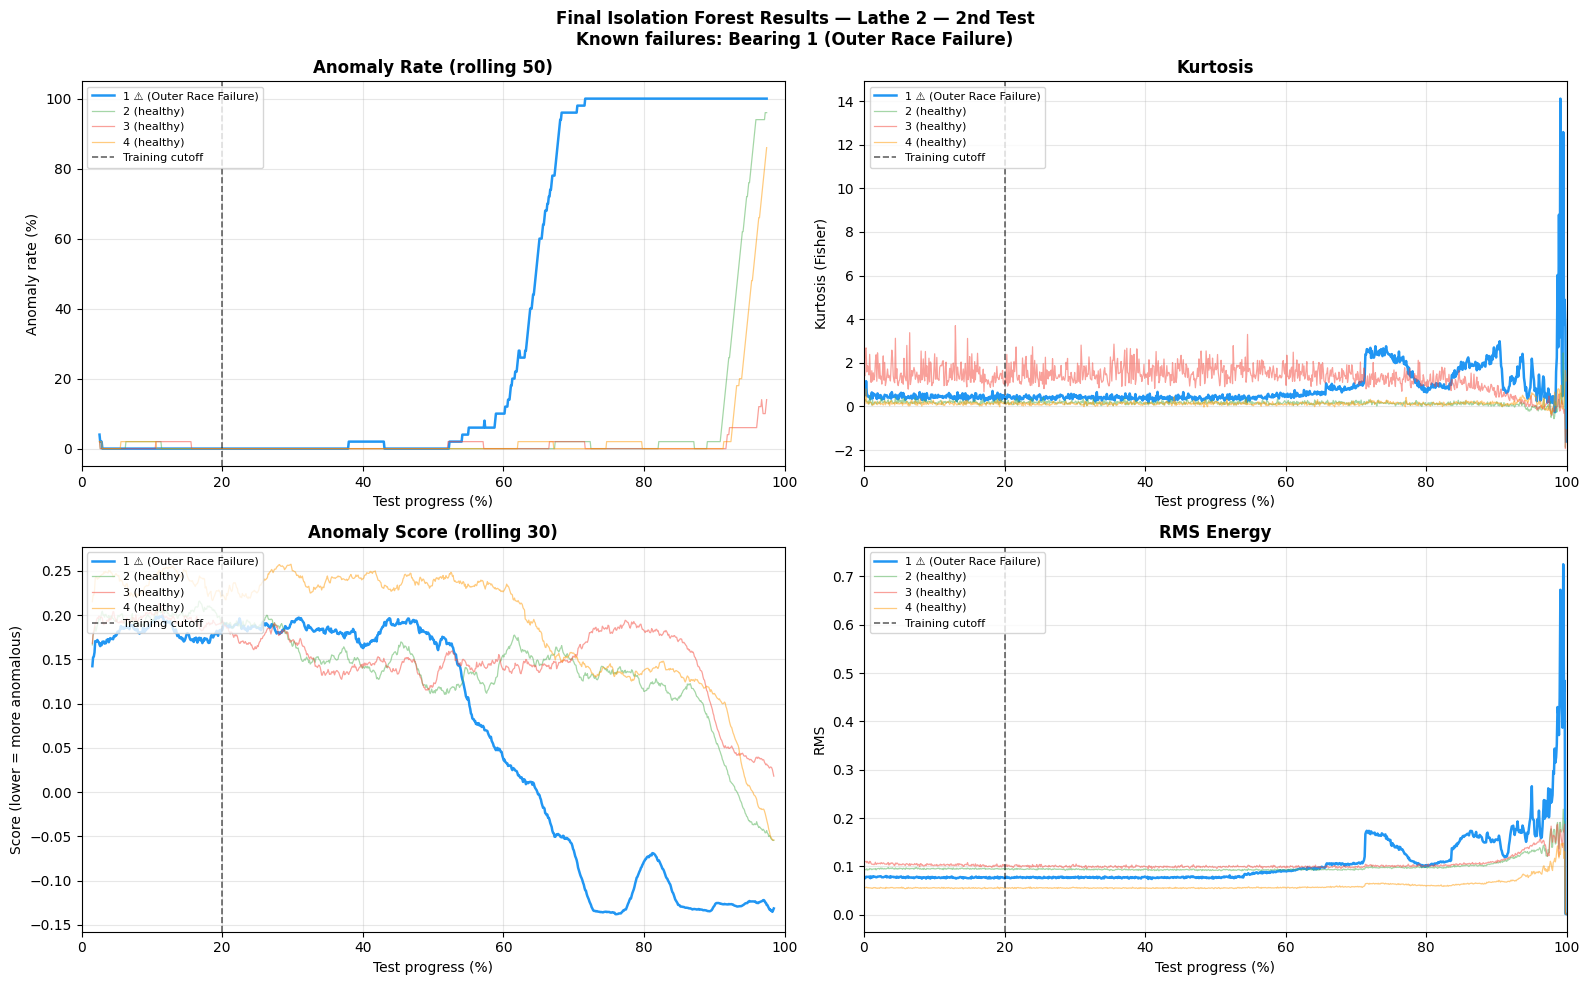

Saved: results\isolation_forest\lathe_2\lathe_2_final_results.png


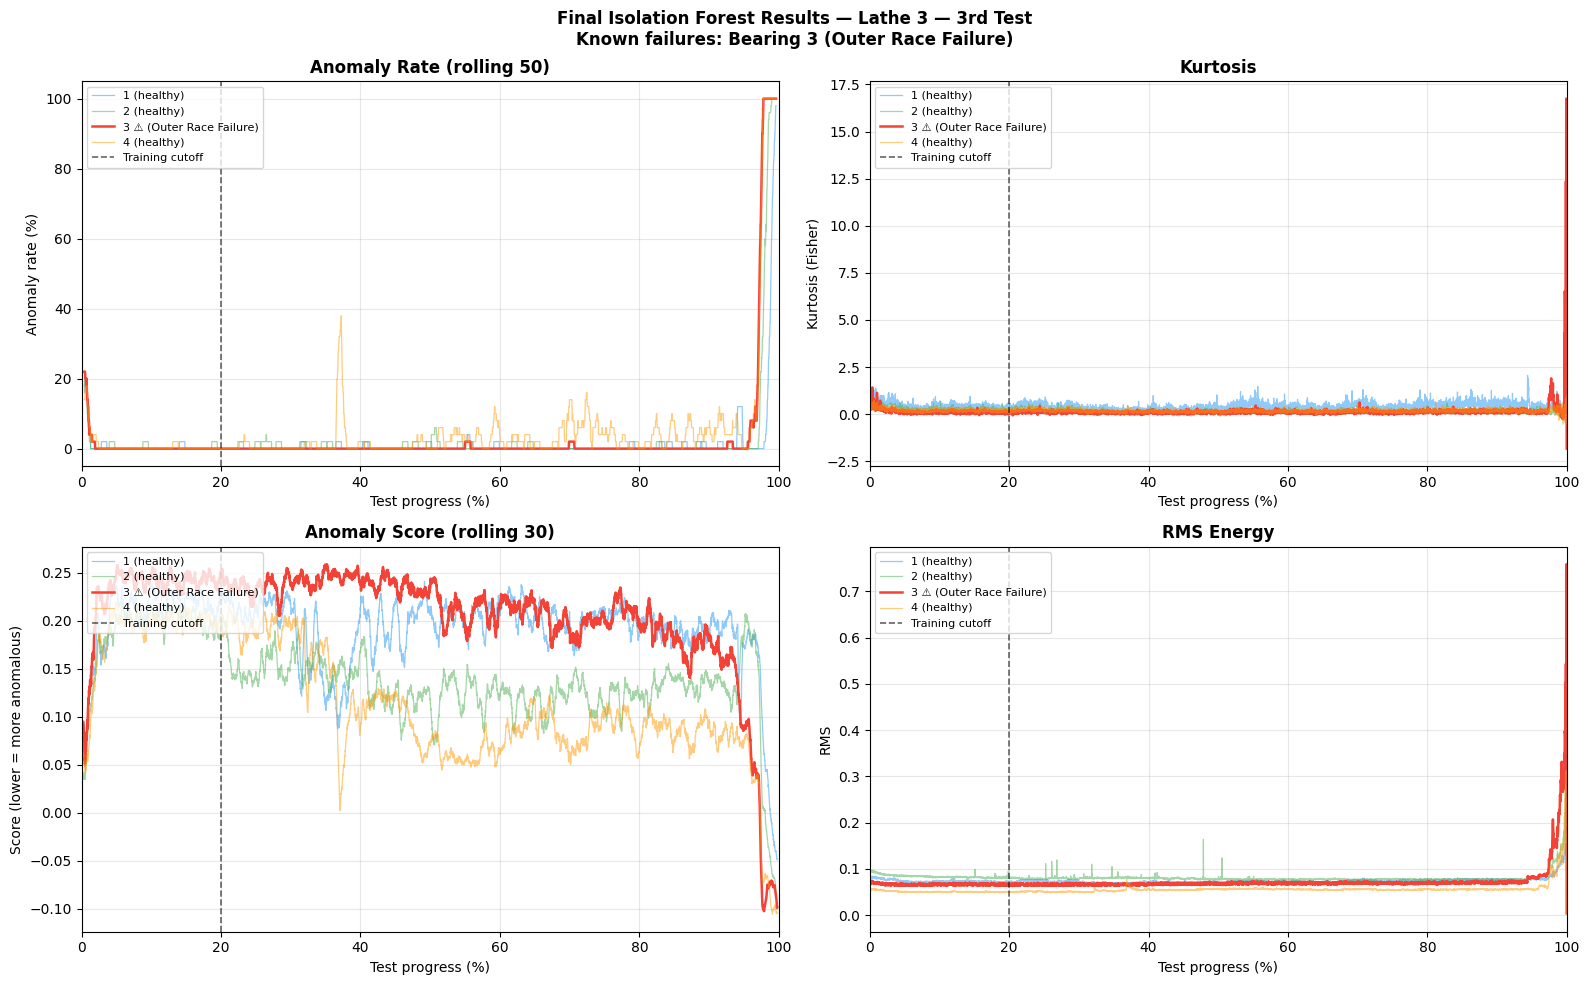

Saved: results\isolation_forest\lathe_3\lathe_3_final_results.png


In [ ]:
# Final summary plots — one per lathe
for tc in TEST_CASES:
    lathe_name     = tc['name']
    known_failures = tc['known_failures']
    lathe_dir      = OUTPUT_DIR / lathe_name
    split_pct      = TRAIN_SPLIT * 100

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    failure_str = ', '.join([f"Bearing {b[-1]} ({v})" for b, v in known_failures.items()])
    fig.suptitle(f'Final Isolation Forest Results — {tc["label"]}\nKnown failures: {failure_str}',
                 fontsize=12, fontweight='bold')

    def add_cutoff(ax):
        ax.axvline(x=split_pct, color='black', linestyle='--',
                   linewidth=1.2, alpha=0.6, label='Training cutoff')

    for bearing_name, df in all_features[lathe_name].items():
        colour  = BEARING_COLOURS[bearing_name]
        is_fail = bearing_name in known_failures
        lw      = 1.8 if is_fail else 0.9
        alpha   = 1.0 if is_fail else 0.5
        label   = f"{bearing_name[-1]} ⚠ ({known_failures.get(bearing_name, '')})" if is_fail else f"{bearing_name[-1]} (healthy)"

        results_df    = pd.read_csv(lathe_dir / f'{bearing_name}_results.csv')
        scores_smooth = pd.Series(results_df['anomaly_score']).rolling(30, center=True).mean()
        anom_smooth   = pd.Series(results_df['is_anomaly'].astype(float)).rolling(50, center=True).mean() * 100

        axes[0, 0].plot(df['progress'], anom_smooth,   color=colour, lw=lw, alpha=alpha, label=label)
        axes[0, 1].plot(df['progress'], df['kurtosis'], color=colour, lw=lw, alpha=alpha, label=label)
        axes[1, 0].plot(df['progress'], scores_smooth, color=colour, lw=lw, alpha=alpha, label=label)
        axes[1, 1].plot(df['progress'], df['rms'],      color=colour, lw=lw, alpha=alpha, label=label)

    for ax in axes.flat:
        add_cutoff(ax)
        ax.set_xlabel('Test progress (%)')
        ax.set_xlim(0, 100)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper left')

    axes[0, 0].set_title('Anomaly Rate (rolling 50)', fontweight='bold'); axes[0, 0].set_ylabel('Anomaly rate (%)')
    axes[0, 1].set_title('Kurtosis', fontweight='bold');                  axes[0, 1].set_ylabel('Kurtosis (Fisher)')
    axes[1, 0].set_title('Anomaly Score (rolling 30)', fontweight='bold'); axes[1, 0].set_ylabel('Score (lower = more anomalous)')
    axes[1, 1].set_title('RMS Energy', fontweight='bold');                axes[1, 1].set_ylabel('RMS')

    plt.tight_layout()
    out = lathe_dir / f'{lathe_name}_final_results.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

In [ ]:
# Verify all model files saved correctly
print('Model bundle verification:')
print('=' * 70)
for tc in TEST_CASES:
    lathe_name = tc['name']
    lathe_dir  = OUTPUT_DIR / lathe_name
    print(f"\n{tc['label']} -> {lathe_dir}")
    for bearing_name in tc['bearings']:
        model_path = lathe_dir / f'{bearing_name}_model.pkl'
        size_kb    = model_path.stat().st_size / 1024
        with open(model_path, 'rb') as f:
            bundle = pickle.load(f)
        print(f'  {model_path.name:<25} {size_kb:>7.1f} KB  '
              f'features={len(bundle["feature_names"])}  '
              f'train_n={bundle["n_train_samples"]}')

print('\nAll bundles verified.')
print('Update RESULTS_DIR in raspi.py to point to the appropriate lathe subfolder.')

Model bundle verification:

Lathe 1 — 1st Test -> results\isolation_forest\lathe_1
  bearing1_model.pkl         1248.5 KB  features=11  train_n=431
  bearing2_model.pkl         1275.7 KB  features=11  train_n=431
  bearing3_model.pkl         1199.7 KB  features=11  train_n=431
  bearing4_model.pkl         1025.8 KB  features=11  train_n=431

Lathe 2 — 2nd Test -> results\isolation_forest\lathe_2
  bearing1_model.pkl          976.2 KB  features=11  train_n=196
  bearing2_model.pkl          941.0 KB  features=11  train_n=196
  bearing3_model.pkl          997.7 KB  features=11  train_n=196
  bearing4_model.pkl          883.1 KB  features=11  train_n=196

Lathe 3 — 3rd Test -> results\isolation_forest\lathe_3
  bearing1_model.pkl         1052.6 KB  features=11  train_n=1264
  bearing2_model.pkl         1061.5 KB  features=11  train_n=1264
  bearing3_model.pkl          973.2 KB  features=11  train_n=1264
  bearing4_model.pkl         1067.9 KB  features=11  train_n=1264

All bundles verified